# Adaptive sampling of functions

`2026/08/19 22:21`

Adaptive sampling is a way to sample functions where they're "interesting".

## PDF informed sampling

Initially, we need to understand how to sample points following a given distribution.
Let's call $g(x)$ the function describing how point-dense a neighborhood around $x$ 
should be. for instance, $g(x) \sim \mathcal{N} (0, 1)$.

If one desires to sample $N + 1$ points for $x \in [a, b]$ following this 
distribution, the $N$ intervals defined by these points will be shorter 
where $g$ is large, this invites the constraining of the area under the curve
of $g(x)$ in the interval $[x_i, x_{i+1}]$ to a fixed value, which means an
**equipartition of area** of $g(x)$:

$$
    \int_{x_i}^{x_{i+1}} g(x) \mathrm d x = \frac{1}{N} \int_{x_i}^{x_{i+1}} g(x) \mathrm d x
$$

If $g(x)$ is normalized, this procedure is essentially a statement that the 
$\{x_i\}$ follow the PDF $g(x)$. Indeed, by computing the antiderivative (CDF):

$$
    G(x) \equiv \int_a^x g(\xi) \mathrm d \xi 
$$
a uniform (or *randomly uniform*) distribution of points on the **image** of $G$
maps to the desired equidistribution in $x$.

How to go about doing this numerically? Given a fine grid of points `x_grid`
and the values of $g$ evaluated there, `g_grid`, the resulting CDF is given 
by something on the lines of:

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline
from scipy.integrate import trapezoid, cumulative_trapezoid

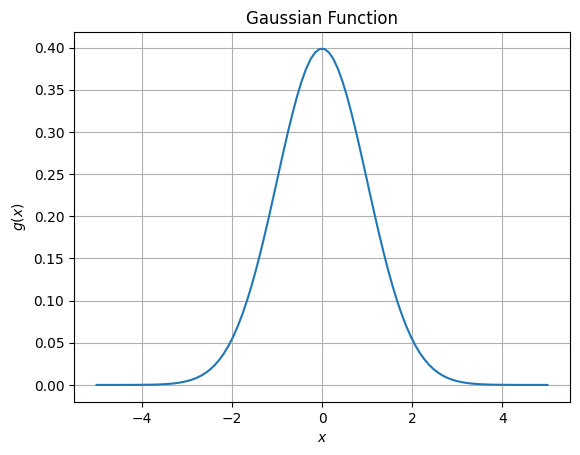

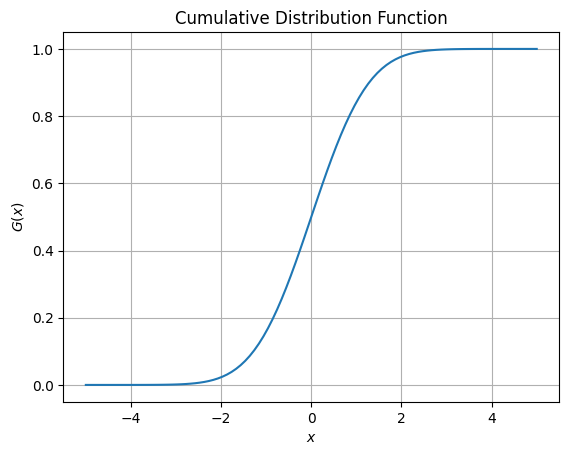

In [52]:
x_grid = np.linspace(-5, 5, 100)
g_grid = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * x_grid**2)

plt.plot(x_grid, g_grid)
plt.xlabel('$x$')
plt.ylabel('$g(x)$')
plt.title('Gaussian Function')
plt.grid()
plt.show()

#cumulative distribution function
G_grid = cumulative_trapezoid(g_grid, x_grid, initial=0)
G_grid /= G_grid[-1]  # Normalize to ensure the CDF goes from 0 to 1
plt.plot(x_grid, G_grid)
plt.xlabel('$x$')
plt.ylabel('$G(x)$')
plt.title('Cumulative Distribution Function')
plt.grid()
plt.show()

Now, How can we invert the cumulative? A simple way is to lineraly interpolate 
the $x$ values in terms of $y$, this will respect the monotone growth of $F(x)$
but may be limited by the grid fineness. Another method is *Piecewise Cubic 
Hermite Interpolating Polynomial* (PCHIP) which uses cubic polynomials but
preserves monotone growth:

In [70]:
from scipy.interpolate import interp1d, pchip_interpolate

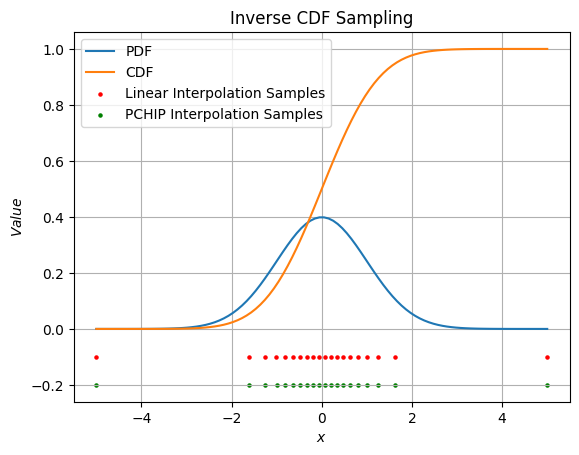

Deviation between linear and PCHIP interpolation samples: -2.3592239273284576e-16


In [73]:
plt.plot(x_grid, g_grid, label='PDF')
plt.plot(x_grid, G_grid, label='CDF')
# Interpolation using linear and PCHIP methods

samples = np.linspace(0, 1, 20)

linear_interp = interp1d(G_grid, x_grid, kind='linear', fill_value="extrapolate")

linear_samples = linear_interp(samples)
pchip_samples = pchip_interpolate(G_grid, x_grid, samples)

plt.scatter(linear_samples, np.zeros_like(linear_samples)-0.1, color='red', label='Linear Interpolation Samples', s=5)
plt.scatter(pchip_samples, np.zeros_like(pchip_samples)-0.2, color='green', label='PCHIP Interpolation Samples', s=5)
plt.ylabel('$Value$')
plt.xlabel('$x$')
plt.title('Inverse CDF Sampling')
plt.legend()
plt.grid()
plt.show()

dev_interps = np.sum(linear_samples - pchip_samples)
print(f'Deviation between linear and PCHIP interpolation samples: {dev_interps}')

Finally, let's look at random sample points following the PDF: 

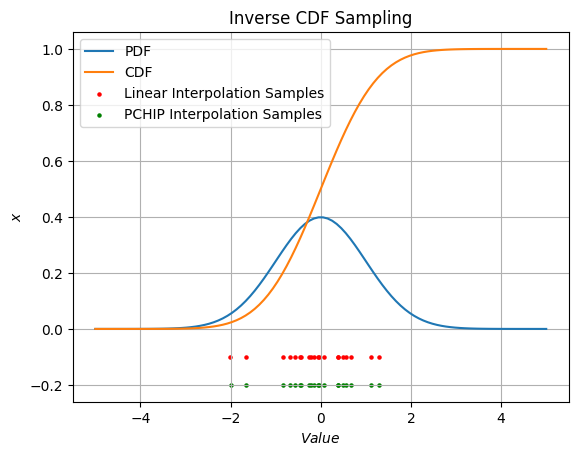

Deviation between linear and PCHIP interpolation samples: 0.00023432378449336766


In [55]:
plt.plot(x_grid, g_grid, label='PDF')
plt.plot(x_grid, G_grid, label='CDF')
# Interpolation using linear and PCHIP methods
linear_interp = interp1d(G_grid, x_grid, kind='linear', fill_value="extrapolate")
pchip_interp = interp1d(G_grid, x_grid, kind='cubic', fill_value="extrapolate")

samples = np.random.uniform(0, 1, 20)
linear_samples = linear_interp(samples)
pchip_samples = pchip_interp(samples)

plt.scatter(linear_samples, np.zeros_like(linear_samples)-0.1, color='red', label='Linear Interpolation Samples', s=5)
plt.scatter(pchip_samples, np.zeros_like(pchip_samples)-0.2, color='green', label='PCHIP Interpolation Samples', s=5)
plt.xlabel('$Value$')
plt.ylabel('$x$')
plt.title('Inverse CDF Sampling')
plt.legend()
plt.grid()
plt.show()

dev_interps = np.sum(linear_samples - pchip_samples)
print(f'Deviation between linear and PCHIP interpolation samples: {dev_interps}')

We loose the automatic sampling of $x=a, b$, but gain a variation in samples
that still follows the PDF.

## Adaptive sampling

Knowing how to sample the points following a distribution, we must now determine
what distribution should be chosen based on what features of a given $f(x)$ we 
would like to sample close to. Taking the following example function as our
model of interest:

In [56]:
x = np.linspace(-3, 5, 1000)
def f(x):
    """Original function."""
    return np.tanh(2*x - 2) - np.exp(-0.5 * (x - 3) ** 2)

def df(x):
    """First derivative of f."""
    # sech^2(z) = 1 / cosh^2(z)
    term1 = 2 / np.cosh(2*x - 2) ** 2
    term2 = (x - 3) * np.exp(-0.5 * (x - 3) ** 2)
    return term1 + term2

def d2f(x):
    """Second derivative of f."""
    u = 2*x - 2
    sech2_u = 1 / np.cosh(u) ** 2
    tanh_u = np.tanh(u)
    term1 = -8 * sech2_u * tanh_u
    term2 = (1 - (x - 3) ** 2) * np.exp(-0.5 * (x - 3) ** 2)
    return term1 + term2

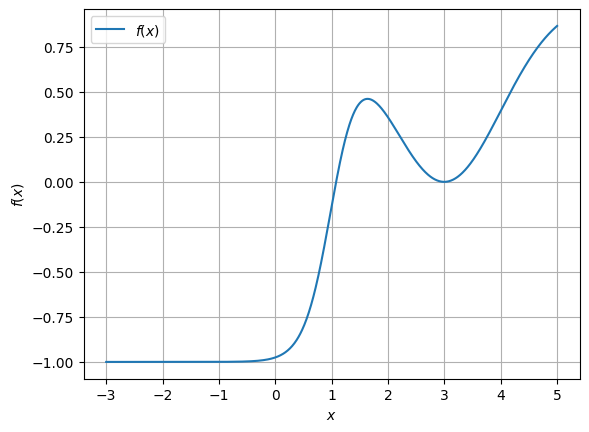

In [57]:
plt.plot(x, f(x), label='$f(x)$')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid()
plt.show()

Let's say we are interested in regions where $f$ "changes a lot", a natural
choice of $g(x)$ would be:

$$
    M(x) \equiv g(x) = |f'(x)|,
$$
where I've introduced the notation for a **Monitor function**, $M(x)$, used 
to select the features of interest of $f(x)$. This choice has a few problems, 
or rather, it is not complete. Where $f'(x)$ is $0$ the density of points will
be essentially zero as well. In our example, the region $[-3, 0]$ Will be left
practically unpopulated. By redefining $M(x) = 1 + \lambda |f'(x)|$ we can 
guarantee there will be a baseline density of points in the "uninsteresting"
parts of $f(x)$, as well as asserting a way of wheigting the derivative feature
by increasing $\lambda$, as there are only so many points to go around!

To be a tad more general, we can write the monitor:

$$
    M(x; \lambda, p) = (1 + \lambda |f'(x)|^p)^{1/p}
$$

This allows for nuance in the sampling rate. Specially, for $\lambda = 1$ and
$p = 2$ We note that the monitor will sample uniformly in arc length!

In [58]:
def monitor_slope(x, lamda, p):
    return (1 + lamda*np.abs(df(x))**p)**(1/p)

In [59]:
def adaptive_samples(a: float, b: float, N: int, monitor: callable, dx: float, interp_method='linear', 
                     sample_method='uniform'):

    """Adaptive sampling based on a monitor function.
    
    Parameters:
        a (float): Start of the interval.
        b (float): End of the interval.
        N (int): Number of samples.
        monitor (callable): Monitor function to determine sampling density.
        dx (float): Step size for the grid.
        interp_method (str): Interpolation method ('linear' or 'pchip').
        sample_method (str): Sampling method ('uniform' or 'random').
    
    Returns:
        np.ndarray: Array of sampled points.
    """

    x_grid = np.arange(a, b+dx, dx)
    g_grid = monitor(x_grid)
    #cumulative distribution function
    G_grid = cumulative_trapezoid(g_grid, x_grid, initial=0)
    G_grid /= G_grid[-1]  # Normalize to ensure the CDF goes from 0 to 1

    if interp_method == 'linear':
        interp = interp1d(G_grid, x_grid, kind='linear', fill_value="extrapolate")
    elif interp_method == 'pchip':
        interp = interp1d(G_grid, x_grid, kind='cubic', fill_value="extrapolate")

    if sample_method == 'uniform':
        samples = np.linspace(0, 1, N)
    elif sample_method == 'random':
        samples = np.random.uniform(0, 1, N)

    interpolated_samples = interp(samples)

    return np.array(interpolated_samples)

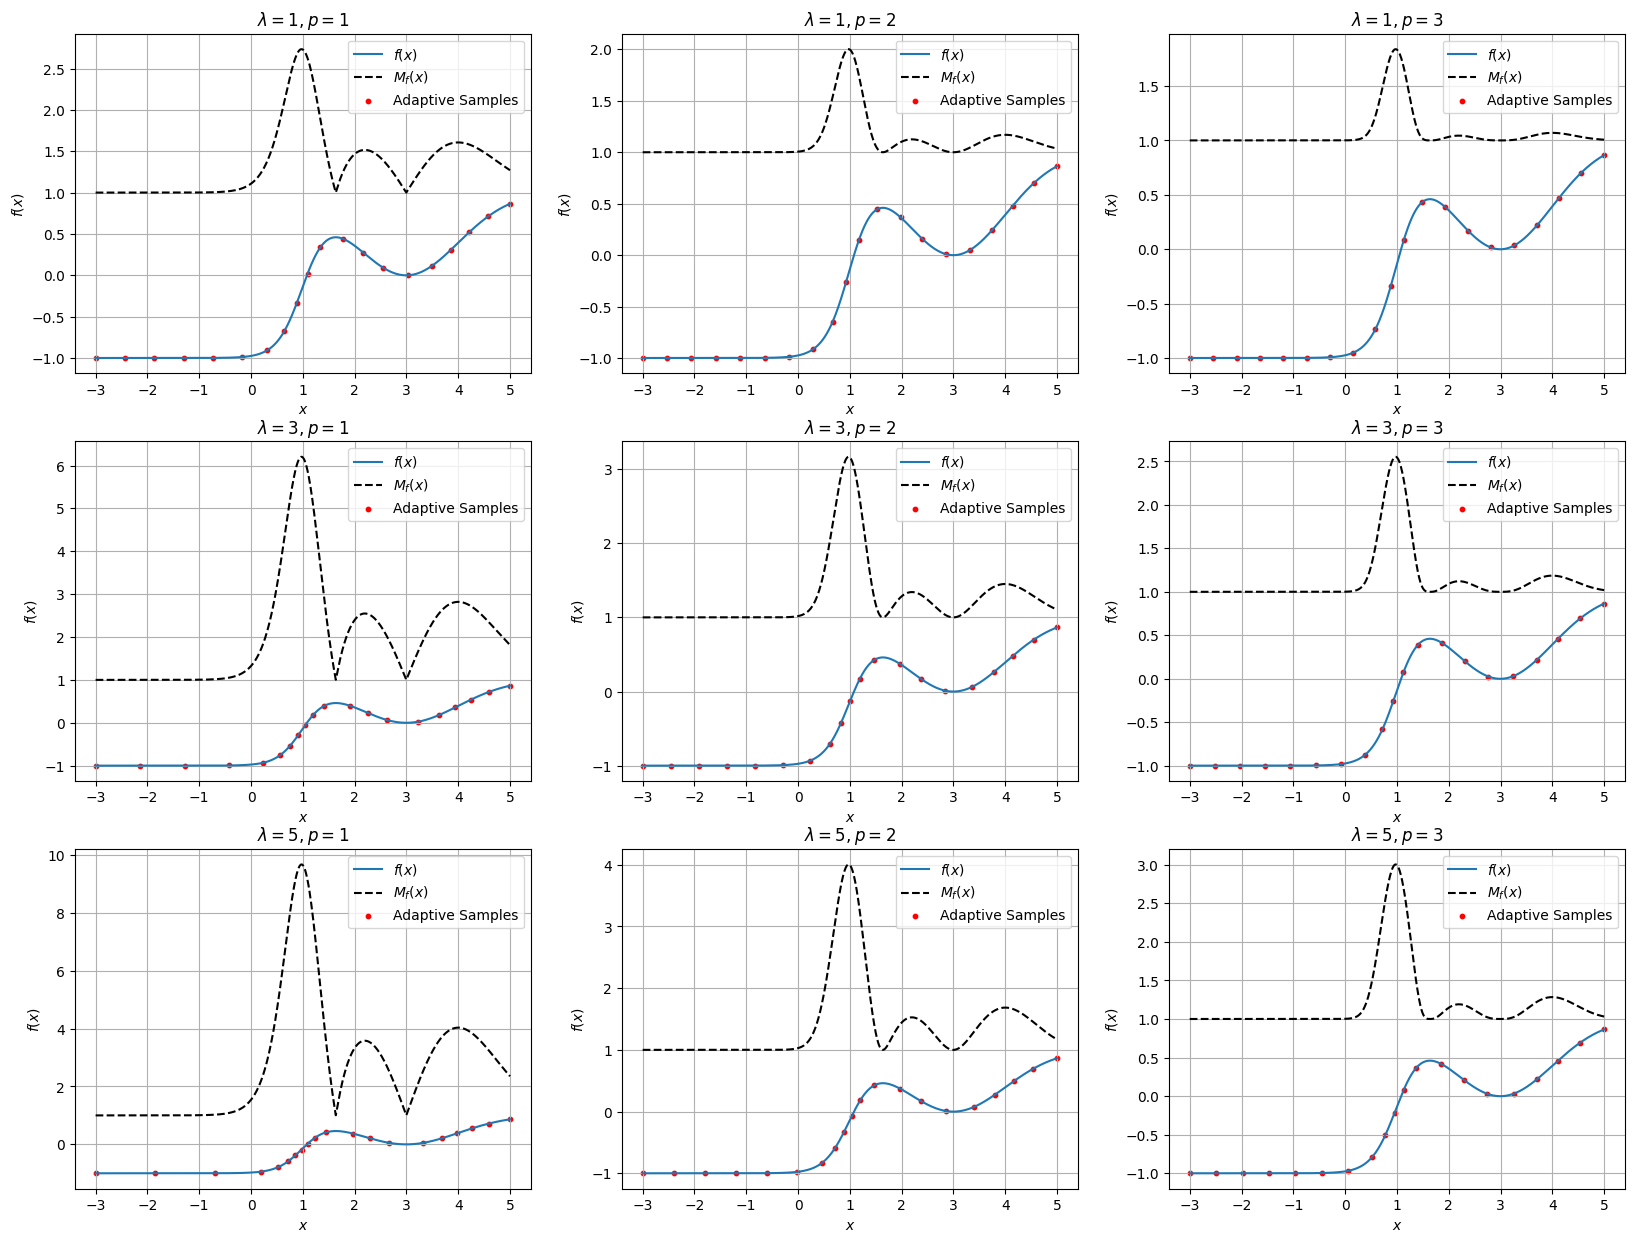

In [60]:
fig, axs = plt.subplots(3, 3, figsize=(20, 15))

i = 0
for lamda in [1, 3, 5]:
    for p in [1, 2, 3]:
        mon = lambda x: monitor_slope(x, lamda, p)
        axs[i//3, i%3].plot(x, f(x), label='$f(x)$')
        axs[i//3, i%3].plot(x, mon(x), label='$M_f(x)$', ls='dashed', c='black')
        samples = adaptive_samples(-3, 5, 20, mon, 0.001, 
                                   interp_method='pchip', 
                                   sample_method='uniform')
        axs[i//3, i%3].scatter(samples, f(samples), color='red', label='Adaptive Samples', s=10)
        axs[i//3, i%3].set_title(f'$\\lambda={lamda}, p={p}$')
        axs[i//3, i%3].set_xlabel('$x$')
        axs[i//3, i%3].set_ylabel('$f(x)$')
        axs[i//3, i%3].grid()
        axs[i//3, i%3].legend()
        i += 1

Another important feature of a function is its local curvature, we can define it as:

$$
    \kappa(x) = \frac{|f''(x)|}{(1 + |f'(x)|^2)^{3/2}}
$$

This suggests the monitor $M(x; \lambda) = 1 + \lambda \kappa(x)$. Let's see a few examples:

In [61]:
def curvature(x):
    return np.abs(d2f(x))/(1 + df(x)**2)**(3/2)

def monitor_curvature(x, lamda):
    return 1 + lamda*curvature(x)

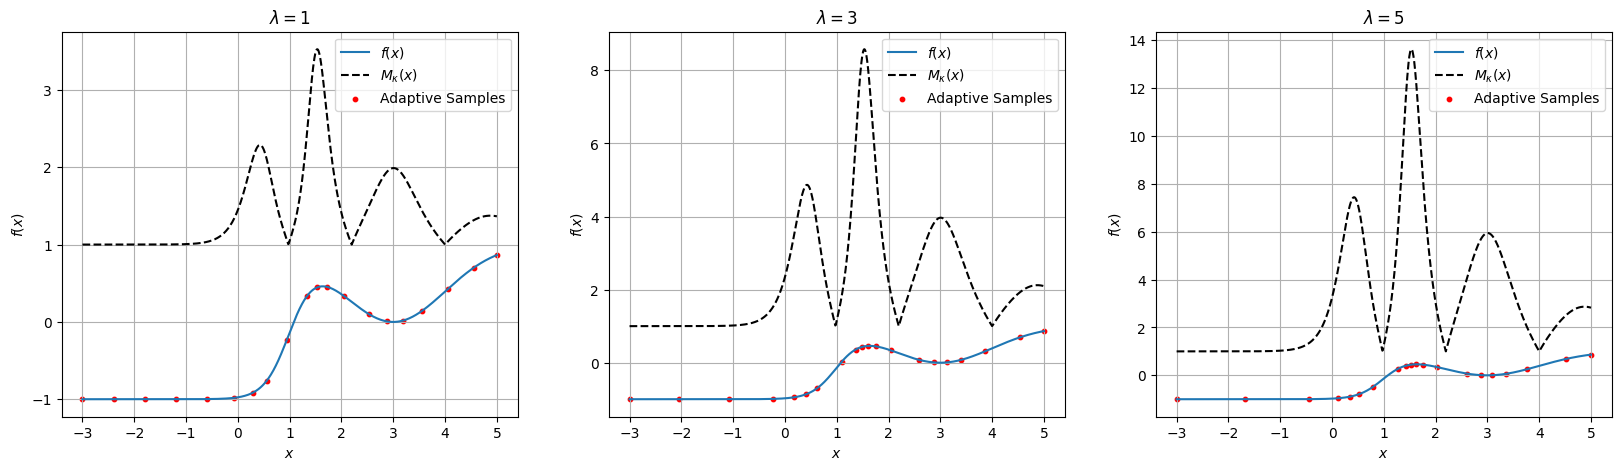

In [62]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

i = 0
for lamda in [1, 3, 5]:
    mon = lambda x: monitor_curvature(x, lamda)
    axs[i].plot(x, f(x), label='$f(x)$')
    axs[i].plot(x, mon(x), label='$M_\\kappa(x)$', ls='dashed', c='black')
    samples = adaptive_samples(-3, 5, 20, mon, 0.001, 
                                interp_method='pchip', 
                                sample_method='uniform')
    axs[i].scatter(samples, f(samples), color='red', label='Adaptive Samples', s=10)
    axs[i].set_title(f'$\\lambda={lamda}$')
    axs[i].set_xlabel('$x$')
    axs[i].set_ylabel('$f(x)$')
    axs[i].grid()
    axs[i].legend()
    i += 1

The beauty of this approach is that the sum of two monitors is also a monitor, 
so nothing stops us from aggregating different monitors to capture multiple
features of a function, with freedom to choose appropriate wheights to each
one.